**ACCESS CONTROL VIOLATION CHECKER (Enterprise-Grade Version)**

A project that simulates and detects unauthorized access attempts using Role-Based Access Control (RBAC) logic, now enhanced with realistic log ingestion, violation analysis, visual insights, and audit-ready reporting.

**Step 1: Design the Schema**

Created 6 core relational tables in SQLite to represent a real-world RBAC structure:

01. Users – Individuals in the system
02. Roles – Role definitions (Admin, Staff, Guest)
03. Permissions – System actions (e.g., view_reports, delete_user)
04. UserRoles – Many-to-many mapping of users to their roles
05. RolePermissions – What each role is allowed to do
06. AccessLogs – What users actually attempted, with timestamps

**Step 2: Simulate & Ingest Realistic Enterprise Logs**

Used a CSV-based access log file (access_logs.csv) with 100+ entries and ~25–30% violations to reflect typical enterprise activity.

01. Users: Alice, Bob, Charlie, Dave
02. Permissions: Valid and invalid actions
03. Logs generated with timestamps and randomized patterns
04. Ingested logs into the database for processing

**Step 3: Detect Access Violations**

Violation Detection Logic:

01. For each user, retrieve assigned roles
02. Aggregate all permissions granted via those roles
03. Compare each log entry to the user's allowed permissions
04. If an action was not authorized by role, mark it as a violation

→ Detected violations are stored in a DataFrame (df_violations)

**Step 4: Export Violations to CSV**

Exported all detected violations to violations_report.csv
This report contains:

01. username, attempted_permission, access_time
02. Whether the action was within the user's permitted scope

Available for download and inclusion in audit packages or GitHub repos.

**Step 5: Generate Access Summary & Insights**

    Part 1: Violation Rate Visualization

            Created a bar chart showing:     
            01. Violation rate per user (%)
            02. Who triggered the most violations
            03. Who attempted the most actions
            04. Helps visually identify high-risk users.

    Part 2: Export access summary (access_summary.csv)

            Summarized each user’s:
            01. Total access attempts
            02. Total violations
            03. Violation rate (%)

            📄 access_summary.csv is ready for:
            01. Dashboards and executive reports
            02. Cross-tool usage (Excel, Power BI, etc.)
            03. Audit logs and performance monitoring

    Part 3: Role-Permission Matrix Export

            Created a matrix mapping:
            01. Each role_name to each permission_name
            02. Format: ✔️ = allowed, ✖️ = not granted

            📄 Exported as role_permission_matrix.csv, useful for:
            01. Security audits
            02. System access reviews
            03. Governance and policy validation

    Part 4: Final Documentation & Packaging
            
            📁 Assembled complete outputs:
            01. Access_Control_Violation_Checker_Enterprise.ipynb
            02. access_logs.csv
            03. violations_report.csv
            04. access_summary.csv
            05. role_permission_matrix.csv
            06. README.md with project overview and usage guide
            
            🗂️ Ready for GitHub or portfolio inclusion.

In [30]:
from google.colab import files
uploaded = files.upload()


Saving access_summary-2.csv to access_summary-2 (1).csv


In [31]:
import sqlite3

# Connect to in-memory SQLite DB
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Users
cursor.execute('''
CREATE TABLE Users (
    user_id INTEGER PRIMARY KEY,
    username TEXT UNIQUE NOT NULL
);
''')

# Roles
cursor.execute('''
CREATE TABLE Roles (
    role_id INTEGER PRIMARY KEY,
    role_name TEXT UNIQUE NOT NULL
);
''')

# Permissions
cursor.execute('''
CREATE TABLE Permissions (
    permission_id INTEGER PRIMARY KEY,
    permission_name TEXT UNIQUE NOT NULL
);
''')

# UserRoles (Many-to-Many)
cursor.execute('''
CREATE TABLE UserRoles (
    user_id INTEGER,
    role_id INTEGER,
    FOREIGN KEY(user_id) REFERENCES Users(user_id),
    FOREIGN KEY(role_id) REFERENCES Roles(role_id)
);
''')

# RolePermissions (Many-to-Many)
cursor.execute('''
CREATE TABLE RolePermissions (
    role_id INTEGER,
    permission_id INTEGER,
    FOREIGN KEY(role_id) REFERENCES Roles(role_id),
    FOREIGN KEY(permission_id) REFERENCES Permissions(permission_id)
);
''')

# AccessLogs
cursor.execute('''
CREATE TABLE AccessLogs (
    log_id INTEGER PRIMARY KEY,
    user_id INTEGER,
    permission_name TEXT,
    access_time TEXT,
    FOREIGN KEY(user_id) REFERENCES Users(user_id)
);
''')

conn.commit()
print("Tables created successfully.")


Tables created successfully.


In [32]:
# Insert Users
users = [('alice',), ('bob',), ('charlie',), ('dave',)]
cursor.executemany("INSERT INTO Users (username) VALUES (?)", users)

# Insert Roles
roles = [('Admin',), ('Staff',), ('Guest',)]
cursor.executemany("INSERT INTO Roles (role_name) VALUES (?)", roles)

# Insert Permissions
permissions = [('view_reports',), ('delete_user',), ('edit_profile',), ('access_dashboard',)]
cursor.executemany("INSERT INTO Permissions (permission_name) VALUES (?)", permissions)

# Map Users to Roles
user_roles = [
    (1, 1),  # alice -> Admin
    (2, 2),  # bob -> Staff
    (3, 3),  # charlie -> Guest
    (4, 2)   # dave -> Staff
]
cursor.executemany("INSERT INTO UserRoles (user_id, role_id) VALUES (?, ?)", user_roles)

# Map Roles to Permissions
role_permissions = [
    (1, 1), (1, 2), (1, 3), (1, 4),  # Admin has all
    (2, 1), (2, 3), (2, 4),          # Staff can't delete
    (3, 3)                           # Guest can only edit profile
]
cursor.executemany("INSERT INTO RolePermissions (role_id, permission_id) VALUES (?, ?)", role_permissions)

# Simulated Access Logs (including violations!)
access_logs = [
    (1, 'view_reports', '2025-06-10 08:00'),     # allowed
    (2, 'edit_profile', '2025-06-10 08:05'),     # allowed
    (2, 'delete_user', '2025-06-10 08:10'),      # violation (Staff)
    (3, 'access_dashboard', '2025-06-10 08:15'), # violation (Guest)
    (4, 'view_reports', '2025-06-10 08:20'),     # allowed
    (4, 'delete_user', '2025-06-10 08:30')       # violation (Staff)
]
cursor.executemany("INSERT INTO AccessLogs (user_id, permission_name, access_time) VALUES (?, ?, ?)", access_logs)

conn.commit()
print("Sample data inserted.")


Sample data inserted.


In [33]:
import pandas as pd

# Load access logs from CSV
df_new_logs = pd.read_csv('access_logs.csv')

# Insert into AccessLogs table
for _, row in df_new_logs.iterrows():
    cursor.execute(
        "INSERT INTO AccessLogs (user_id, permission_name, access_time) VALUES ((SELECT user_id FROM Users WHERE username = ?), ?, ?)",
        (row['username'], row['permission_name'], row['timestamp'])
    )
conn.commit()
print(" Access logs from CSV inserted into database.")


 Access logs from CSV inserted into database.


In [34]:
import pandas as pd

# Step 1: Get permission_id to name mapping
cursor.execute("SELECT * FROM Permissions")
perm_map = {row[1]: row[0] for row in cursor.fetchall()}

# Step 2: Build a set of allowed permissions for each user
cursor.execute("""
SELECT ur.user_id, rp.permission_id
FROM UserRoles ur
JOIN RolePermissions rp ON ur.role_id = rp.role_id
""")
user_permissions = {}
for user_id, permission_id in cursor.fetchall():
    user_permissions.setdefault(user_id, set()).add(permission_id)

# Step 3: Check each log against user's allowed permissions
cursor.execute("""
SELECT al.log_id, u.username, al.user_id, al.permission_name, al.access_time
FROM AccessLogs al
JOIN Users u ON u.user_id = al.user_id
""")
logs = cursor.fetchall()

violation_data = []
for log_id, username, user_id, permission_name, access_time in logs:
    perm_id = perm_map.get(permission_name)
    allowed = perm_id in user_permissions.get(user_id, set())
    if not allowed:
        violation_data.append({
            "log_id": log_id,
            "username": username,
            "user_id": user_id,
            "attempted_permission": permission_name,
            "access_time": access_time,
            "violation": True
        })

# Convert to DataFrame
df_violations = pd.DataFrame(violation_data)
print("Violations detected.")
df_violations


Violations detected.


,log_id,username,user_id,attempted_permission,access_time,violation
0,3,bob,2,delete_user,2025-06-10 08:10,True
1,4,charlie,3,access_dashboard,2025-06-10 08:15,True
2,6,dave,4,delete_user,2025-06-10 08:30,True
3,11,dave,4,delete_user,2025-06-05 16:56:31,True
4,14,bob,2,delete_user,2025-06-06 14:55:31,True
5,17,bob,2,delete_user,2025-06-05 12:49:31,True
6,23,charlie,3,access_dashboard,2025-06-06 17:43:31,True
7,24,dave,4,delete_user,2025-06-04 16:53:31,True
8,30,dave,4,delete_user,2025-06-10 13:05:31,True
9,35,bob,2,delete_user,2025-06-10 13:30:31,True


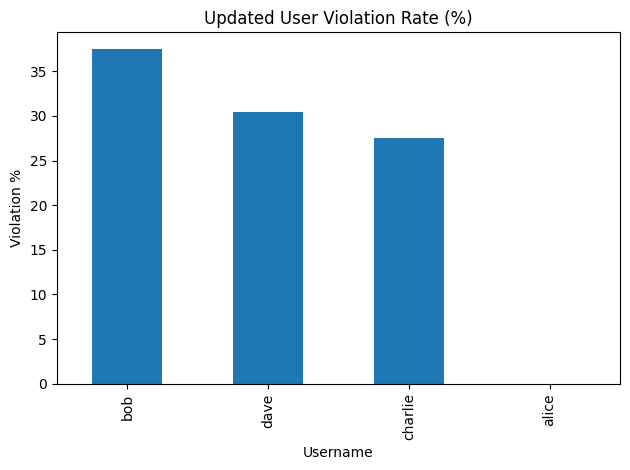

In [35]:
# Regenerate summary stats
access_counts = df_new_logs.groupby('username').size().reset_index(name='total_accesses')
violation_counts = df_violations.groupby('username').size().reset_index(name='violations')
summary = pd.merge(access_counts, violation_counts, on='username', how='left')
summary['violations'] = summary['violations'].fillna(0).astype(int)
summary['violation_rate (%)'] = round((summary['violations'] / summary['total_accesses']) * 100, 2)

# Plot updated violation rates
import matplotlib.pyplot as plt

summary.sort_values(by='violation_rate (%)', ascending=False).plot(
    x='username', y='violation_rate (%)', kind='bar', legend=False,
    title='Updated User Violation Rate (%)', ylabel='Violation %', xlabel='Username'
)
plt.tight_layout()
plt.show()


In [36]:
# Re-export updated violations
df_violations.to_csv("violations_report.csv", index=False)
from google.colab import files
files.download("violations_report.csv")

# Re-export updated summary
summary.to_csv("access_summary.csv", index=False)
from google.colab import files
files.download("access_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Export the summary to CSV
summary.to_csv("access_summary.csv", index=False)

# Enable download in Colab
from google.colab import files
files.download("access_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
query = """
SELECT r.role_name, p.permission_name
FROM RolePermissions rp
JOIN Roles r ON rp.role_id = r.role_id
JOIN Permissions p ON rp.permission_id = p.permission_id
"""
df_matrix = pd.read_sql_query(query, conn)

# Optional pivot to matrix format
role_perm_matrix = df_matrix.pivot_table(
    index='role_name',
    columns='permission_name',
    aggfunc=lambda x: '✔️',
    fill_value='✖️'
)

# Export to CSV
role_perm_matrix.to_csv("role_permission_matrix.csv")
from google.colab import files
files.download("role_permission_matrix.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
readme_content = """
# Access Control Violation Checker 🔐

A security-focused project that simulates and detects unauthorized access attempts using Role-Based Access Control (RBAC) logic. Built with Python, SQLite, and Google Colab.

## 📌 Features
- Realistic access log ingestion from CSV with intentional violations
- Role-Permission matrix and User-Role mapping
- Violation detection engine with logic checks
- Summary stats and CSV export of results
- Visual insights for risk and user behavior analysis

## 🧪 Tech Stack
- Python (pandas, matplotlib, sqlite3)
- SQLite (in-memory DB)
- Google Colab

## 📁 Outputs
- `access_logs.csv`: Simulated access logs (input file)
- `violations_report.csv`: All detected violations
- `access_summary.csv`: Access attempts and violation rate per user
- `role_permission_matrix.csv`: Permissions assigned to each role

## 🚀 How to Use
1. Open the `Access_Control_Violation_Checker_Enterprise.ipynb` notebook in Google Colab
2. Upload the `access_logs.csv` file
3. Run cells sequentially
4. View visualizations and download generated reports

## 📊 Example Use Case
A security audit team ingests real-time access logs to detect users performing actions beyond their assigned roles (e.g., Guests accessing dashboards or Staff deleting users).

## 📧 Contact
Madhu Pappula – Graduate Student in MIS
GitHub: [your-link] • Email: [your-email]
"""

# Save to file
with open("README.md", "w") as f:
    f.write(readme_content.strip())

# Download from Colab
from google.colab import files
files.download("README.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Access-Control-Violation-Checker**

01. access_control_checker.ipynb        ------ Main Colab notebook
02. violations_report.csv               ------ Exported violation logs
03. access_summary.csv                  ------ Exported access summary
04. role_permission_matrix.csv          ------ Role-permission matrix
05. README.md                           ------ Project overview and usage


# Access Control Violation Checker 🔐

A security-focused project that simulates and detects unauthorized access attempts using Role-Based Access Control (RBAC) logic. Built with Python, SQLite, and Google Colab.

## 📌 Features
- Realistic access log ingestion from CSV with intentional violations
- Role-Permission matrix and User-Role mapping
- Violation detection engine with logic checks
- Summary stats and CSV export of results
- Visual insights for risk and user behavior analysis

## 🧪 Tech Stack
- Python (pandas, matplotlib, sqlite3)
- SQLite (in-memory DB)
- Google Colab

## 📁 Outputs
- `access_logs.csv`: Simulated access logs (input file)
- `violations_report.csv`: All detected violations
- `access_summary.csv`: Access attempts and violation rate per user
- `role_permission_matrix.csv`: Permissions assigned to each role

## 🚀 How to Use
1. Open the `Access_Control_Violation_Checker_Enterprise.ipynb` notebook in Google Colab
2. Upload the `access_logs.csv` file
3. Run cells sequentially
4. View visualizations and download generated reports

## 📊 Example Use Case
A security audit team ingests real-time access logs to detect users performing actions beyond their assigned roles (e.g., Guests accessing dashboards or Staff deleting users).

## 📧 Contact
Madhu Pappula – Graduate Student in MIS  
GitHub: [your-link] • Email: [your-email]
